In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as  np
import matplotlib.pyplot as  plt
import plotly.express as px
import polars as pl
import os
import streamlit as st

In [2]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"]=r'C:\Users\QC#\Downloads\dbt-learning-493706-81ad6e669580.json'
client=bigquery.Client()

In [3]:
df="""
select * from `dbt-learning-493706.dbt_manas.marts_chicago_crime_sample`
"""
df=pl.from_arrow(client.query(df).result().to_arrow()
                         )

In [4]:
df

crime_id,case_number,crime_date,crime_time,crime_hour,crime_day,crime_month,crime_year,crime_week_days,report_latancy_days,is_arrest,is_domestic,block,x_coordinate,y_coordinate,latitude,longitude,location_description,district,ward,community_area,crime_location,crime_beat,crime_category,crime_description
str,str,date,time,i64,i64,i64,i64,i64,i64,i64,i64,str,f64,f64,f64,f64,str,str,f64,f64,str,str,str,str
"""13482620""","""JH290436""",2024-06-03,13:40:00,13,3,6,2024,2,348,0,0,"""012XX S AVERS AVE""",1.150906e6,1.894173e6,41.865502,-87.721493,"""RESIDENCE PORCH/HALLWAY""","""10""",24.0,29.0,"""(41.865540884, -87.721496664)""","""1011""","""THEFT""","""OVER $500"""
"""13877475""","""JJ306212""",2025-06-23,19:30:00,19,23,6,2025,2,264,1,0,"""012XX S AVERS AVE""",1.150908e6,1.894098e6,41.865297,-87.721488,"""RESIDENCE PORCH/HALLWAY""","""10""",24.0,29.0,"""(41.865540884, -87.721496664)""","""1011""","""NARCOTICS""","""POSS: PCP"""
"""13568938""","""JH394167""",2024-08-18,19:30:00,19,18,8,2024,1,272,0,1,"""012XX S AVERS AVE""",1.150905e6,1.894214e6,41.865615,-87.721496,"""RESIDENCE PORCH/HALLWAY""","""10""",24.0,29.0,"""(41.865540884, -87.721496664)""","""1011""","""BATTERY""","""DOMESTIC BATTERY SIMPLE"""
"""14037894""","""JJ500181""",2025-11-23,22:50:00,22,23,11,2025,1,111,0,1,"""012XX S AVERS AVE""",1.150909e6,1.894078e6,41.865242,-87.721485,"""RESIDENCE PORCH/HALLWAY""","""10""",24.0,29.0,"""(41.865540884, -87.721496664)""","""1011""","""BATTERY""","""AGGRAVATED DOMESTIC BATTERY: K…"
"""13957302""","""JJ402837""",2025-09-05,10:45:00,10,5,9,2025,6,190,1,0,"""012XX S AVERS AVE""",1.150903e6,1.894261e6,41.865744,-87.721502,"""RESIDENCE PORCH/HALLWAY""","""10""",24.0,29.0,"""(41.865540884, -87.721496664)""","""1011""","""NARCOTICS""","""POSS: CRACK"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""14035115""","""JJ496914""",2025-11-21,05:25:00,5,21,11,2025,6,113,0,0,"""054XX S WELLS ST""",1.175552e6,1.868549e6,41.79467,-87.631785,"""GAS STATION""","""9""",20.0,37.0,"""(41.794670403, -87.631785431)""","""935""","""THEFT""","""OVER $500"""
"""13535167""","""JH353906""",2024-07-19,21:30:00,21,19,7,2024,6,302,1,0,"""054XX S WELLS ST""",1.175552e6,1.868549e6,41.79467,-87.631785,"""GAS STATION""","""9""",20.0,37.0,"""(41.794670403, -87.631785431)""","""935""","""MOTOR VEHICLE THEFT""","""AUTOMOBILE"""
"""28263""","""JH346129""",2024-07-14,08:12:00,8,14,7,2024,1,100,1,0,"""054XX S WELLS ST""",1.175552e6,1.868549e6,41.79467,-87.631785,"""GAS STATION""","""9""",20.0,37.0,"""(41.794670403, -87.631785431)""","""935""","""HOMICIDE""","""FIRST DEGREE MURDER"""


In [5]:
chicago_crime=df.to_pandas()

In [6]:
chicago_crime

,crime_id,case_number,crime_date,crime_time,crime_hour,crime_day,crime_month,crime_year,crime_week_days,report_latancy_days,...,latitude,longitude,location_description,district,ward,community_area,crime_location,crime_beat,crime_category,crime_description
0,13482620,JH290436,2024-06-03,13:40:00,13,3,6,2024,2,348,...,41.865502,-87.721493,RESIDENCE PORCH/HALLWAY,10,24.0,29.0,"(41.865540884, -87.721496664)",1011,THEFT,OVER $500
1,13877475,JJ306212,2025-06-23,19:30:00,19,23,6,2025,2,264,...,41.865297,-87.721488,RESIDENCE PORCH/HALLWAY,10,24.0,29.0,"(41.865540884, -87.721496664)",1011,NARCOTICS,POSS: PCP
2,13568938,JH394167,2024-08-18,19:30:00,19,18,8,2024,1,272,...,41.865615,-87.721496,RESIDENCE PORCH/HALLWAY,10,24.0,29.0,"(41.865540884, -87.721496664)",1011,BATTERY,DOMESTIC BATTERY SIMPLE
3,14037894,JJ500181,2025-11-23,22:50:00,22,23,11,2025,1,111,...,41.865242,-87.721485,RESIDENCE PORCH/HALLWAY,10,24.0,29.0,"(41.865540884, -87.721496664)",1011,BATTERY,AGGRAVATED DOMESTIC BATTERY: KNIFE/CUTTING INST
4,13957302,JJ402837,2025-09-05,10:45:00,10,5,9,2025,6,190,...,41.865744,-87.721502,RESIDENCE PORCH/HALLWAY,10,24.0,29.0,"(41.865540884, -87.721496664)",1011,NARCOTICS,POSS: CRACK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
592364,14035115,JJ496914,2025-11-21,05:25:00,5,21,11,2025,6,113,...,41.794670,-87.631785,GAS STATION,9,20.0,37.0,"(41.794670403, -87.631785431)",935,THEFT,OVER $500
592365,13535167,JH353906,2024-07-19,21:30:00,21,19,7,2024,6,302,...,41.794670,-87.631785,GAS STATION,9,20.0,37.0,"(41.794670403, -87.631785431)",935,MOTOR VEHICLE THEFT,AUTOMOBILE
592366,28263,JH346129,2024-07-14,08:12:00,8,14,7,2024,1,100,...,41.794670,-87.631785,GAS STATION,9,20.0,37.0,"(41.794670403, -87.631785431)",935,HOMICIDE,FIRST DEGREE MURDER
592367,13342182,JH120522,2024-01-18,10:30:00,10,18,1,2024,5,338,...,41.795675,-87.631855,GAS STATION,9,20.0,37.0,"(41.794670403, -87.631785431)",935,MOTOR VEHICLE THEFT,AUTOMOBILE


In [7]:
chicago_crime.isna().sum()

crime_id                   0
case_number                0
crime_date                 0
crime_time                 0
crime_hour                 0
crime_day                  0
crime_month                0
crime_year                 0
crime_week_days            0
report_latancy_days        0
is_arrest                  0
is_domestic                0
block                      0
x_coordinate            3181
y_coordinate            3181
latitude                3181
longitude               3181
location_description       0
district                   0
ward                       0
community_area             0
crime_location          6074
crime_beat                 0
crime_category             0
crime_description          0
dtype: int64

In [8]:
chicago_crime.duplicated().sum()

np.int64(0)

In [9]:
hourly_crime_rate=chicago_crime['crime_hour'].value_counts().reset_index().sort_values(by="crime_hour")
hourly_crime_rate

,crime_hour,count
0,0,40383
17,1,19345
18,2,17385
19,3,15431
21,4,12574
23,5,10901
22,6,11687
20,7,15272
16,8,20614
14,9,24634


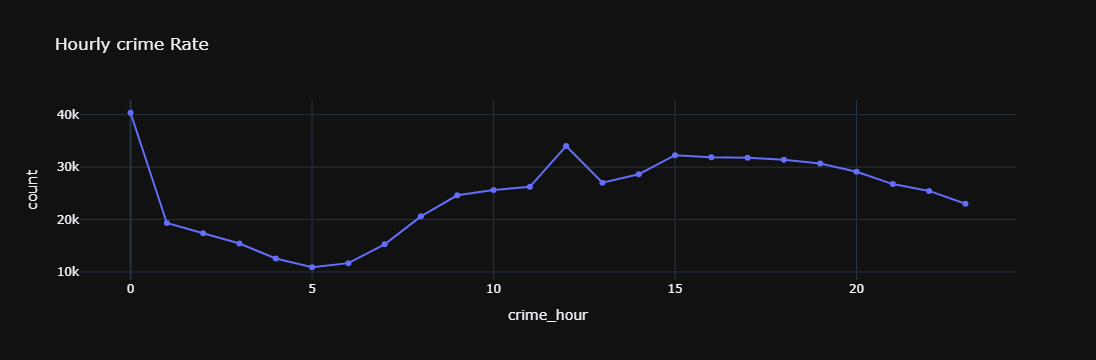

In [10]:
fig_line=px.line(
    hourly_crime_rate,
    x="crime_hour",
    y="count",
    title="Hourly crime Rate",
    markers=True,
    template="plotly_dark"
)
fig_line.show()

In [11]:
yearly_crime_rate=chicago_crime['crime_year'].value_counts().reset_index()
yearly_crime_rate

,crime_year,count
0,2024,259162
1,2025,237398
2,2026,95809


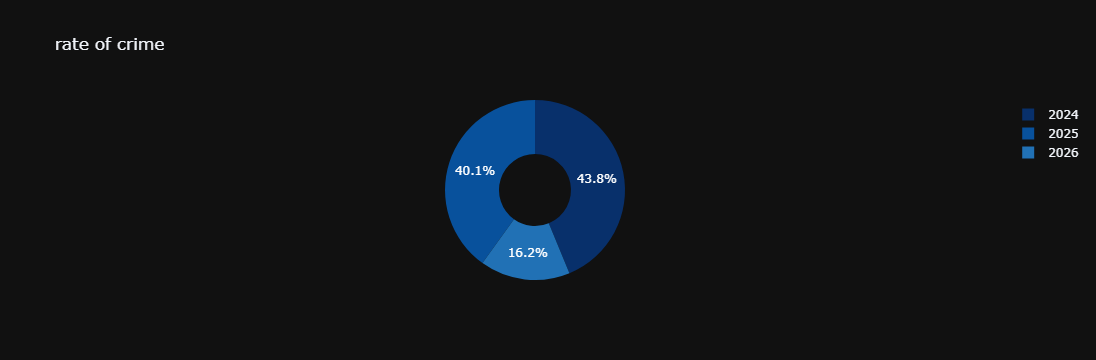

In [12]:
fig_pie=px.pie(
    yearly_crime_rate,
    values='count',
    names='crime_year',
    title='rate of crime',
    template='plotly_dark',
    hole=.4,
    color_discrete_sequence=px.colors.sequential.Blues_r
)
fig_pie.show()

In [13]:
weekly_crime_rate=chicago_crime['crime_week_days'].value_counts().reset_index().sort_values(by="crime_week_days")
weekly_crime_rate

,crime_week_days,count
5,1,83286
2,2,85378
6,3,83138
3,4,83967
4,5,83358
0,6,87064
1,7,86178


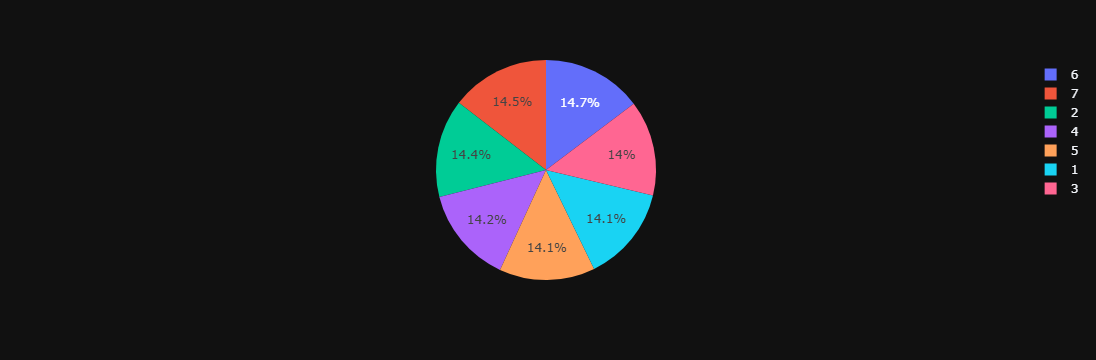

In [14]:
fig_sunburst=px.pie(
    weekly_crime_rate,
    values='count',
    names='crime_week_days',
    template='plotly_dark'
)
fig_sunburst.show()

In [15]:
monthly_crime_rate=chicago_crime['crime_month'].value_counts().reset_index()
monthly_crime_rate

,crime_month,count
0,5,64101
1,3,59695
2,4,59085
3,1,55074
4,2,52952
5,6,48271
6,7,46763
7,8,44338
8,10,43481
9,9,43337


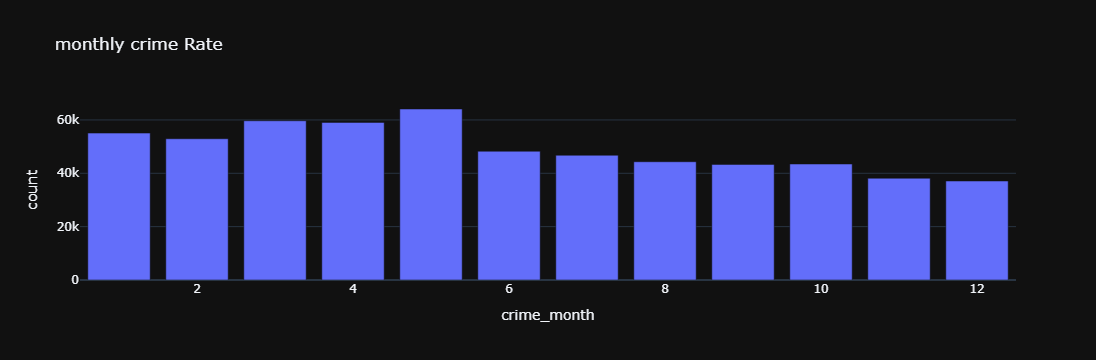

In [16]:
fig_line=px.bar(
    monthly_crime_rate,
    x="crime_month",
    y="count",
    title="monthly crime Rate",
    template="plotly_dark"
)
fig_line.show()

In [17]:
crime_category=chicago_crime['crime_category'].value_counts().head(10)
crime_category

crime_category
THEFT                  136578
BATTERY                106409
CRIMINAL DAMAGE         65139
ASSAULT                 53704
MOTOR VEHICLE THEFT     46532
OTHER OFFENSE           40584
DECEPTIVE PRACTICE      36877
BURGLARY                23930
ROBBERY                 16743
NARCOTICS               16192
Name: count, dtype: int64

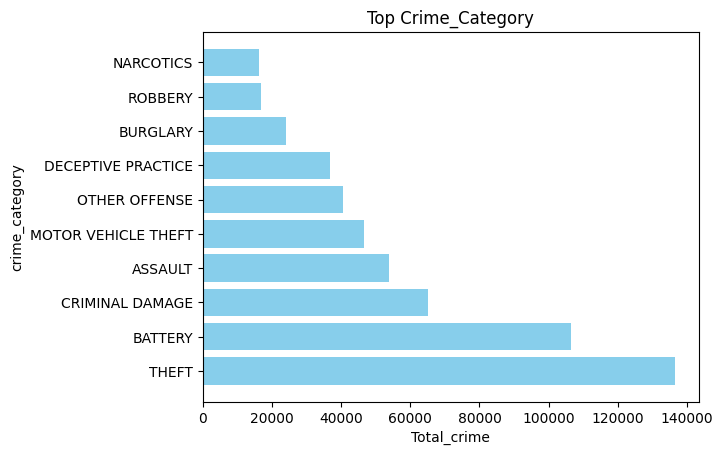

In [18]:
plt.barh(crime_category.index,crime_category.values,color='skyblue'),
plt.title("Top Crime_Category")
plt.xlabel("Total_crime")
plt.ylabel("crime_category")
plt.show()

In [19]:
top_arrest_by_crime_type=chicago_crime.groupby('crime_category')['is_arrest'].mean().sort_values(ascending=False).reset_index().head(10)
top_arrest_by_crime_type

,crime_category,is_arrest
0,CONCEALED CARRY LICENSE VIOLATION,0.974684
1,GAMBLING,0.973684
2,NARCOTICS,0.951149
3,LIQUOR LAW VIOLATION,0.944444
4,PROSTITUTION,0.934783
5,PUBLIC INDECENCY,0.909091
6,INTERFERENCE WITH PUBLIC OFFICER,0.893069
7,WEAPONS VIOLATION,0.690168
8,NON-CRIMINAL,0.571429
9,OTHER NARCOTIC VIOLATION,0.555556


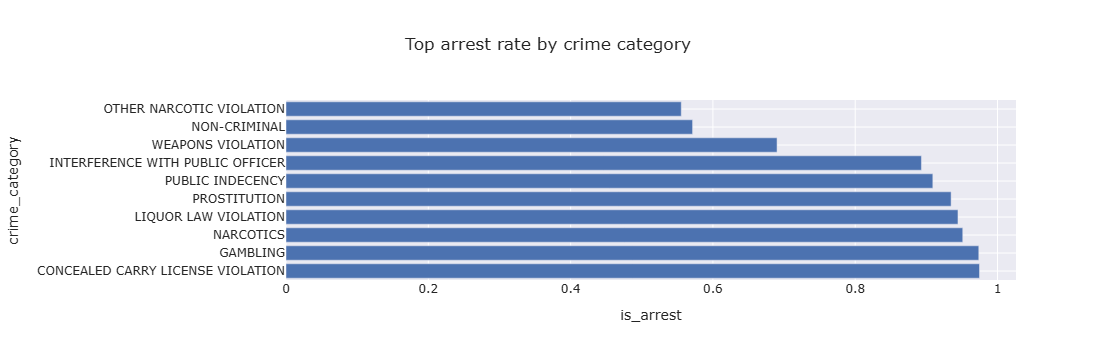

In [20]:
fig_arrest1=px.bar(
    top_arrest_by_crime_type,
    x='is_arrest',
    y='crime_category',
    title='Top arrest rate by crime category',
    template='seaborn'
)
fig_arrest1.show()  

In [21]:
arrest_by_crime_type=chicago_crime.groupby('crime_category')['is_arrest'].mean().sort_values(ascending=False).reset_index().tail(10)
arrest_by_crime_type

,crime_category,is_arrest
21,THEFT,0.080804
22,KIDNAPPING,0.078261
23,STALKING,0.051737
24,BURGLARY,0.046218
25,CRIMINAL DAMAGE,0.041711
26,CRIM SEXUAL ASSAULT,0.039378
27,MOTOR VEHICLE THEFT,0.031978
28,DECEPTIVE PRACTICE,0.030642
29,INTIMIDATION,0.026442
30,HUMAN TRAFFICKING,0.023810


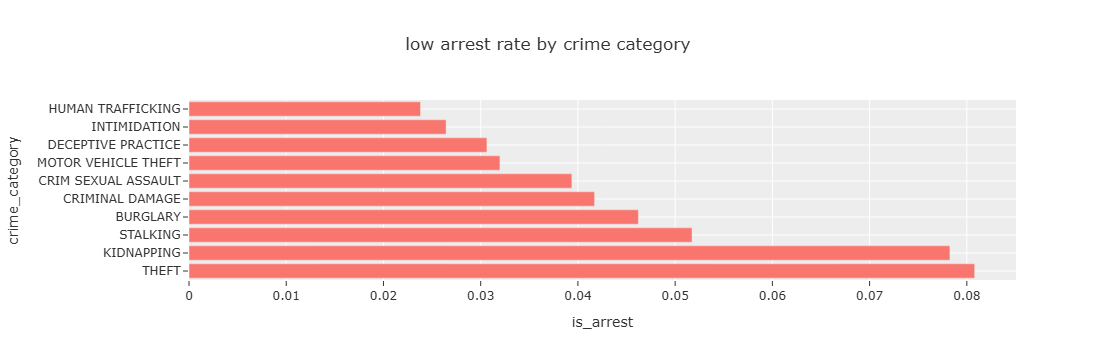

In [22]:
fig_arrest2=px.bar(
    arrest_by_crime_type,
    x='is_arrest',
    y='crime_category',
    title='low arrest rate by crime category',
    template='ggplot2'
)
fig_arrest2.show()  

In [23]:
location_df=chicago_crime['location_description'].value_counts().head(10).reset_index()
location_df

,location_description,count
0,STREET,149104
1,SIDEWALK,80624
2,RESIDENCE,77428
3,APARTMENT,68936
4,ALLEY,19927
5,OTHER,15793
6,PARKING LOT/GARAGE(NON.RESID.),13936
7,SMALL RETAIL STORE,12627
8,RESTAURANT,11349
9,RESIDENCE PORCH/HALLWAY,10967


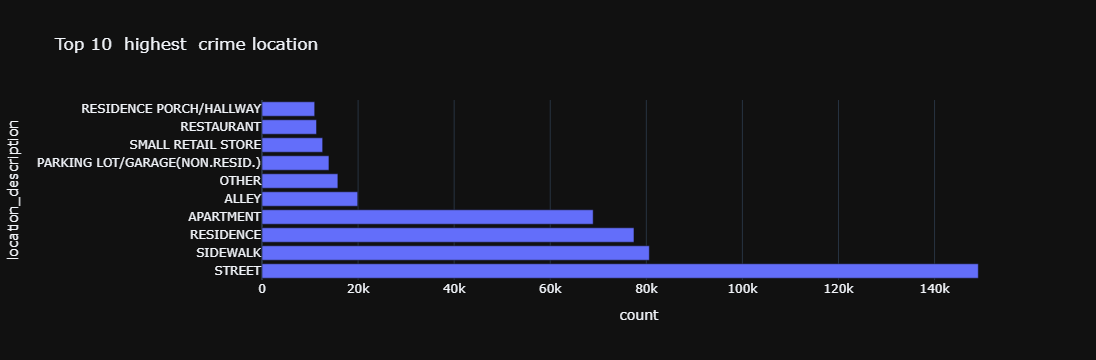

In [24]:
fig_top_location=px.bar(
    location_df,
    x='count',
    y='location_description',
    title='Top 10  highest  crime location',
    template='plotly_dark'
)
fig_top_location.show()  

In [25]:
arrest_rate=chicago_crime['is_arrest'].value_counts().reset_index()
arrest_rate

,is_arrest,count
0,0,503865
1,1,88504


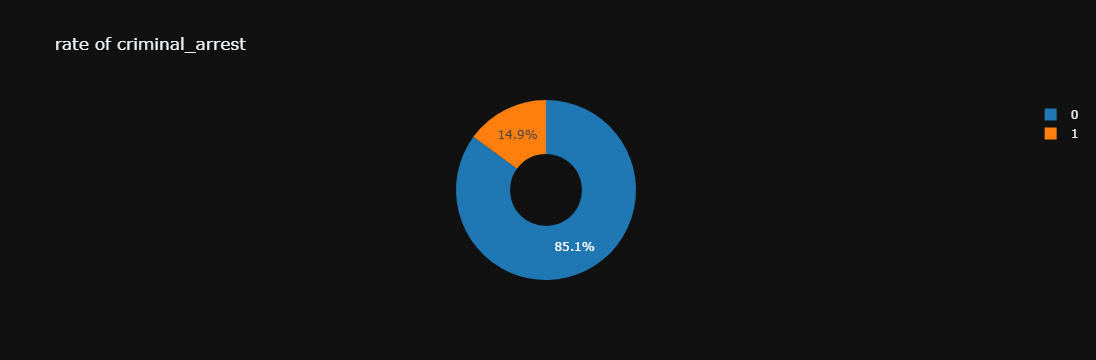

In [26]:
fig_arrest_rate=px.pie(
    arrest_rate,
    values='count',
    names='is_arrest',
    title='rate of criminal_arrest',
    template='plotly_dark',
    hole=.4,
    color_discrete_sequence=px.colors.qualitative.D3
)
fig_arrest_rate.show()

In [27]:
domestic_crime_rate=chicago_crime['is_domestic'].value_counts().reset_index()
domestic_crime_rate

,is_domestic,count
0,0,481086
1,1,111283


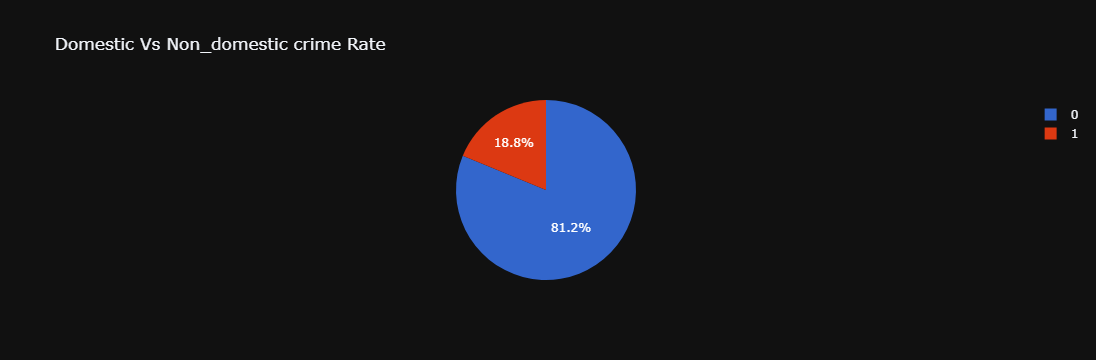

In [28]:
fig_domest_rate=px.pie(
    domestic_crime_rate,
    values='count',
    names='is_domestic',
    title='Domestic Vs Non_domestic crime Rate',
    template='plotly_dark',
    color_discrete_sequence=px.colors.qualitative.G10
)
fig_domest_rate.show()